# PA3 Section 2.1 Pendulum SAC — Visualization Notebook

Training is done by scripts. This notebook only loads logs, creates plots/tables, and generates rollout videos/GIFs.

## Checklist

- Evaluation starts at timestep 0.
- Evaluation is deterministic/greedy.
- Each evaluation point averages 20 episodes.
- Pendulum uses 500 initial random-action steps.
- CI is over seeds, not episodes.
- Default torque limits are unchanged.

In [1]:
from pathlib import Path
import json
import pandas as pd

OUTPUT_ROOT = Path('../outputs/pendulum_final_300k_clean')
PLOTS_DIR = OUTPUT_ROOT / 'plots'
VIDEOS_DIR = OUTPUT_ROOT / 'videos'
OUTPUT_ROOT, PLOTS_DIR, VIDEOS_DIR

(PosixPath('../outputs/pendulum_final_300k_clean'),
 PosixPath('../outputs/pendulum_final_300k_clean/plots'),
 PosixPath('../outputs/pendulum_final_300k_clean/videos'))

## Load combined logs

In [2]:
import sys
sys.path.append('..')
from pendulum_sac_lib import load_all_eval_logs, load_all_train_logs

eval_df = load_all_eval_logs(OUTPUT_ROOT)
train_df = load_all_train_logs(OUTPUT_ROOT)
print(eval_df.shape, train_df.shape)
eval_df.head()

(9300, 23) (90000, 11)


,eval_return_mean,eval_return_std_over_episodes,eval_length_mean,mean_abs_angle_error_rad,mean_abs_angle_error_deg,mean_abs_angular_velocity,mean_squared_torque,target_occupancy,timestep,seed,...,manual_alpha,alpha,condition,wallclock_seconds,mean_q1_loss_since_last_eval,mean_q2_loss_since_last_eval,mean_actor_loss_since_last_eval,mean_alpha_loss_since_last_eval,mean_alpha_since_last_eval,seed_dir
0,-3201.585477,1030.885971,1000.0,1.594621,91.365037,1.168254,0.026166,0.0086,0,0,...,0.2,0.2,manual_target_p090_alpha_0p2_scale_1,NaN,NaN,NaN,NaN,NaN,NaN,../outputs/pendulum_final_300k_clean/manual_ta...
1,-2918.858454,2416.847357,1000.0,1.321497,75.716226,1.525723,2.334952,0.0126,10000,0,...,0.2,0.2,manual_target_p090_alpha_0p2_scale_1,67.317237,0.431101,0.479851,42.660059,0.0,0.2,../outputs/pendulum_final_300k_clean/manual_ta...
2,-1584.139901,151.727927,1000.0,1.240767,71.090735,0.080583,2.778780,0.0010,20000,0,...,0.2,0.2,manual_target_p090_alpha_0p2_scale_1,138.736573,0.233054,0.284271,91.148133,0.0,0.2,../outputs/pendulum_final_300k_clean/manual_ta...
3,-1541.237980,85.807523,1000.0,1.229017,70.417471,0.060433,2.888318,0.0010,30000,0,...,0.2,0.2,manual_target_p090_alpha_0p2_scale_1,211.072197,0.170984,0.254604,121.505339,0.0,0.2,../outputs/pendulum_final_300k_clean/manual_ta...
4,-1557.652908,114.134583,1000.0,1.230381,70.495662,0.074048,2.881617,0.0007,40000,0,...,0.2,0.2,manual_target_p090_alpha_0p2_scale_1,283.761060,0.100134,0.156261,137.586459,0.0,0.2,../outputs/pendulum_final_300k_clean/manual_ta...


## Select manual alphas after manual-search stage

In [3]:
# Run this after scripts/run_02_manual_search.sh if you want to recompute selection inside notebook.
!python ../select_manual_alphas.py --output-root {OUTPUT_ROOT} --tuning-seeds 0,1,2

selected = json.loads((OUTPUT_ROOT / 'selected_manual_alphas.json').read_text())
selected

Selected manual alphas:
  target -60° -> alpha=0.03
  target 90° -> alpha=0.01
  target 120° -> alpha=0.01
  target -150° -> alpha=0.01
Wrote ../outputs/pendulum_final_300k_clean/selected_manual_alphas.json
Wrote ../outputs/pendulum_final_300k_clean/manual_alpha_selection_table.csv


{'selection_rule': '0.5*normalized_final_return + 0.5*normalized_AUC',
 'tuning_seeds': [0, 1, 2],
 'selected_alphas': {'-60.0': 0.03,
  '90.0': 0.01,
  '120.0': 0.01,
  '-150.0': 0.01}}

## Generate required plots

In [4]:
# Raw required plots
!python ../make_pendulum_plots.py --output-root {OUTPUT_ROOT} --smooth-window 1

# Supplementary smoothed plots for readability
!python ../make_pendulum_plots.py --output-root {OUTPUT_ROOT} --smooth-window 3

Wrote 18 plots to ../outputs/pendulum_final_300k_clean/plots
  ../outputs/pendulum_final_300k_clean/plots/auto_all_targets_eval_return_mean.png
  ../outputs/pendulum_final_300k_clean/plots/manual_vs_auto_panels_eval_return_mean.png
  ../outputs/pendulum_final_300k_clean/plots/reward_scaling_panels_eval_return_mean.png
  ../outputs/pendulum_final_300k_clean/plots/auto_all_targets_mean_abs_angle_error_deg.png
  ../outputs/pendulum_final_300k_clean/plots/manual_vs_auto_panels_mean_abs_angle_error_deg.png
  ../outputs/pendulum_final_300k_clean/plots/reward_scaling_panels_mean_abs_angle_error_deg.png
  ../outputs/pendulum_final_300k_clean/plots/auto_all_targets_target_occupancy.png
  ../outputs/pendulum_final_300k_clean/plots/manual_vs_auto_panels_target_occupancy.png
  ../outputs/pendulum_final_300k_clean/plots/reward_scaling_panels_target_occupancy.png
  ../outputs/pendulum_final_300k_clean/plots/auto_all_targets_mean_abs_angular_velocity.png
  ../outputs/pendulum_final_300k_clean/plots/m

## Display key plots

../outputs/pendulum_final_300k_clean/plots/auto_all_targets_eval_return_mean.png


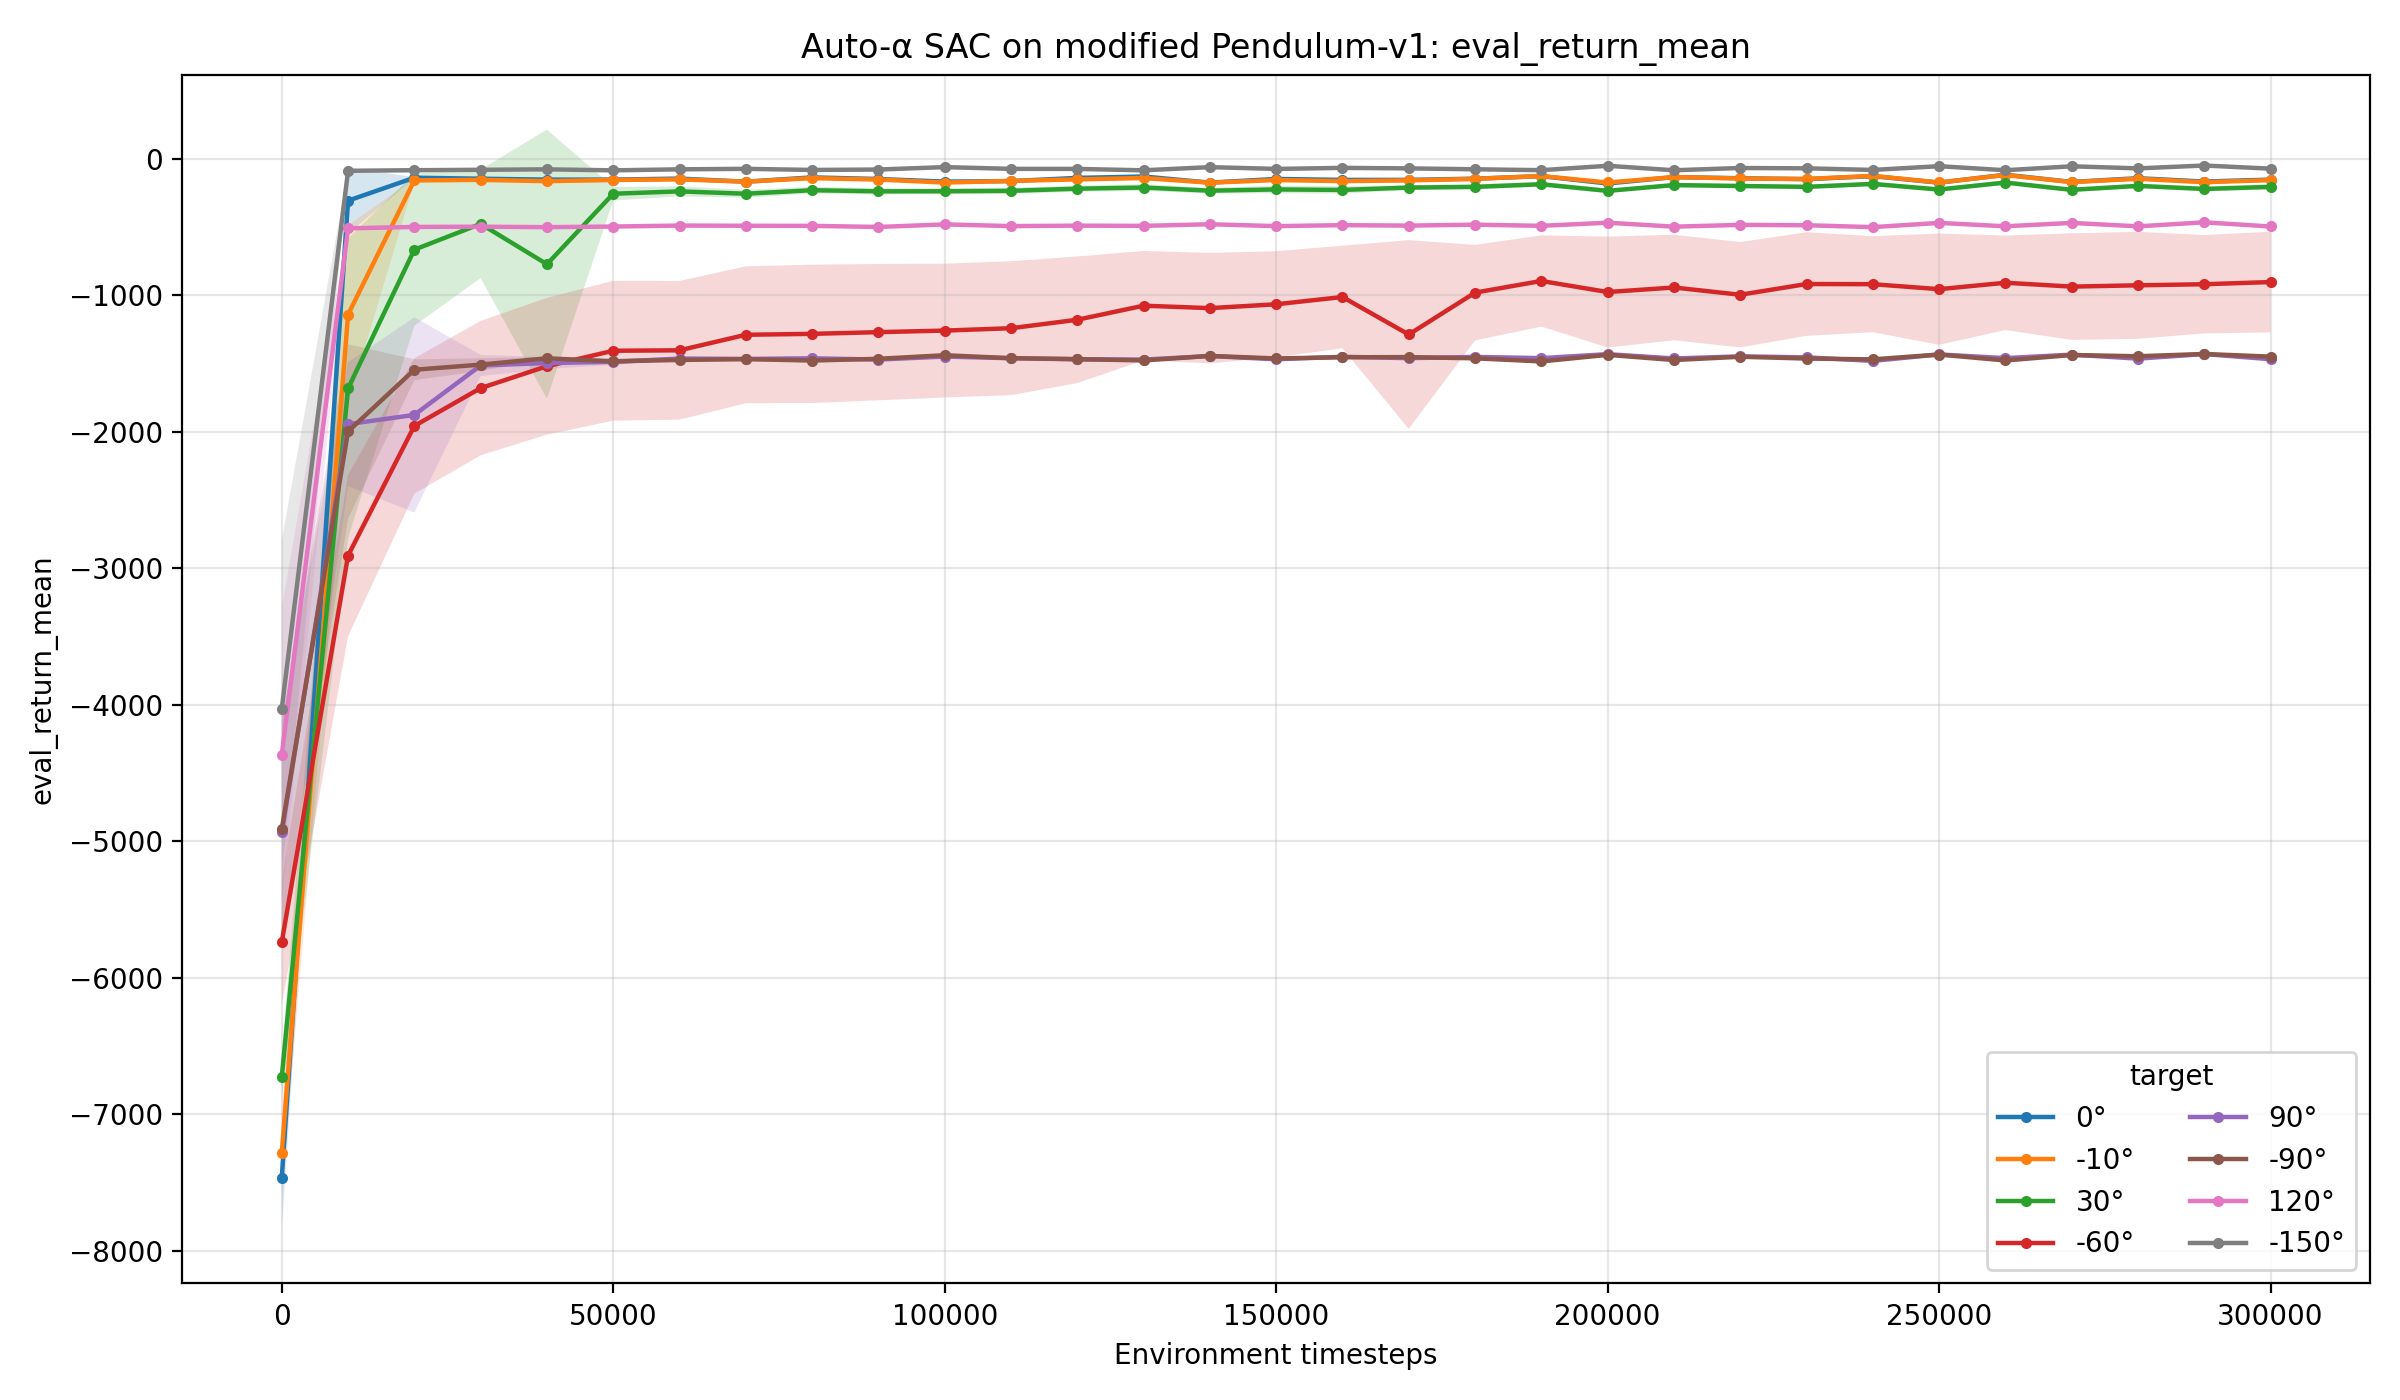

../outputs/pendulum_final_300k_clean/plots/manual_vs_auto_panels_eval_return_mean.png


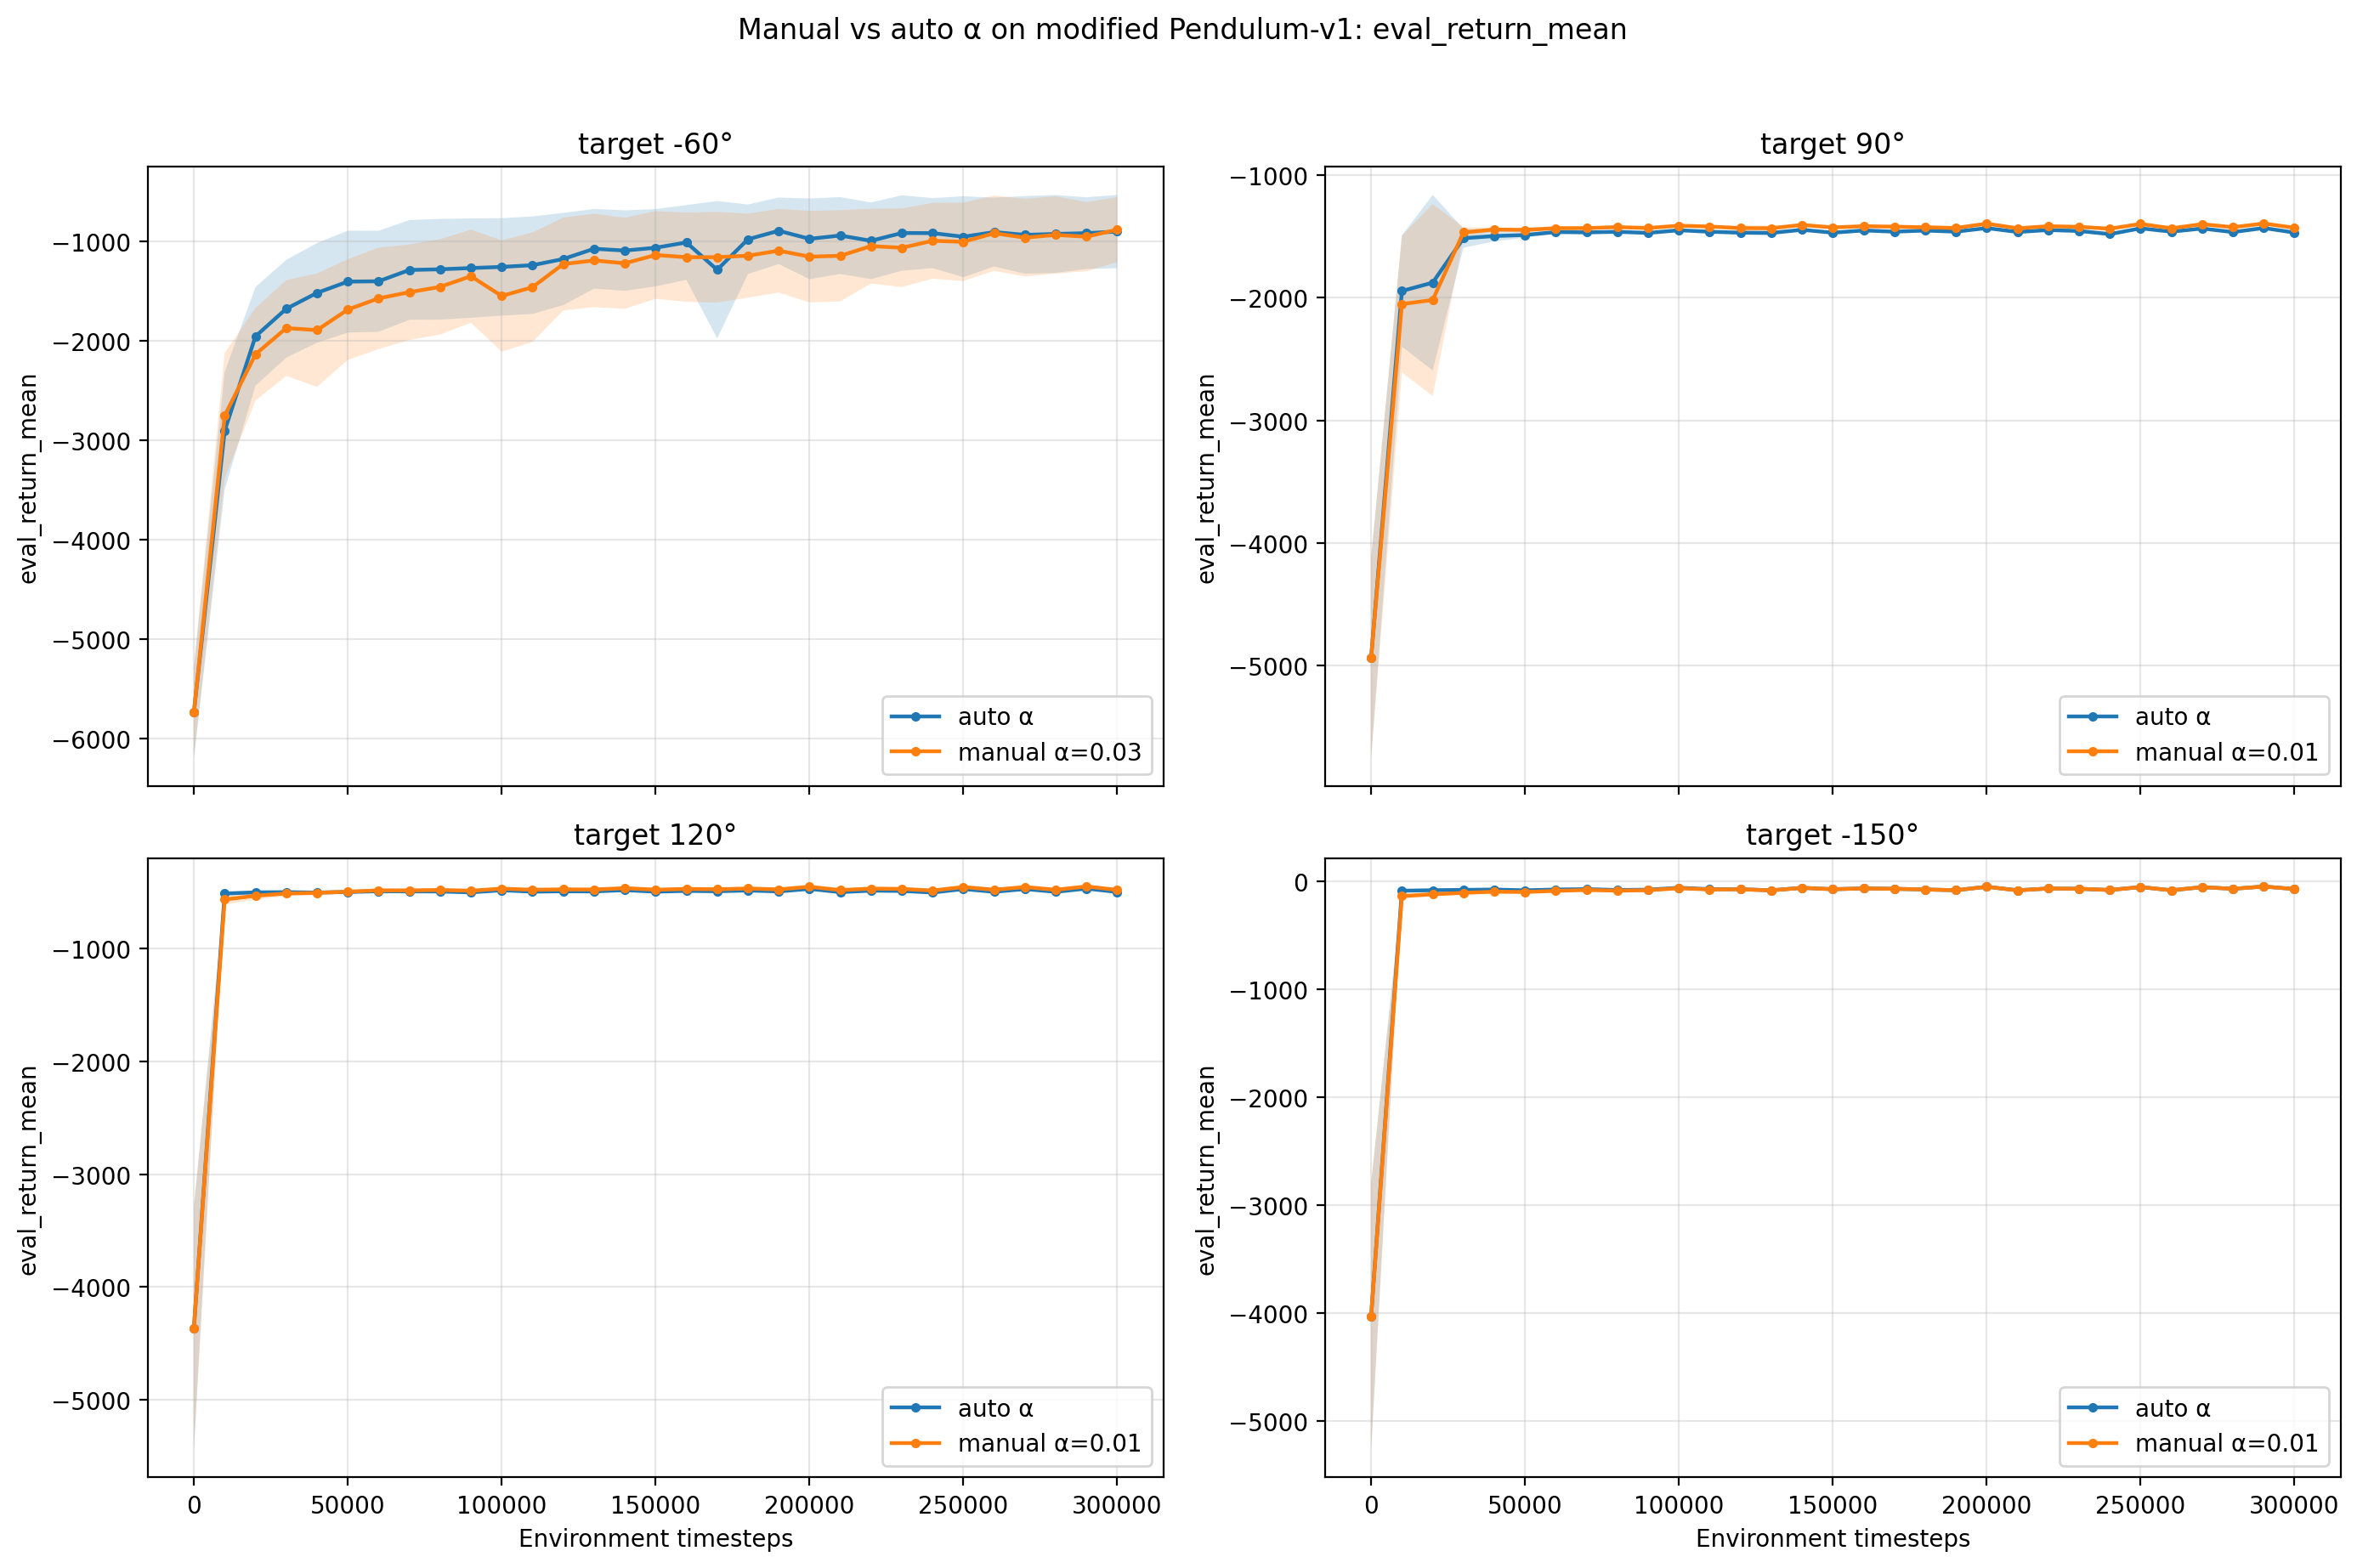

../outputs/pendulum_final_300k_clean/plots/reward_scaling_panels_eval_return_mean.png


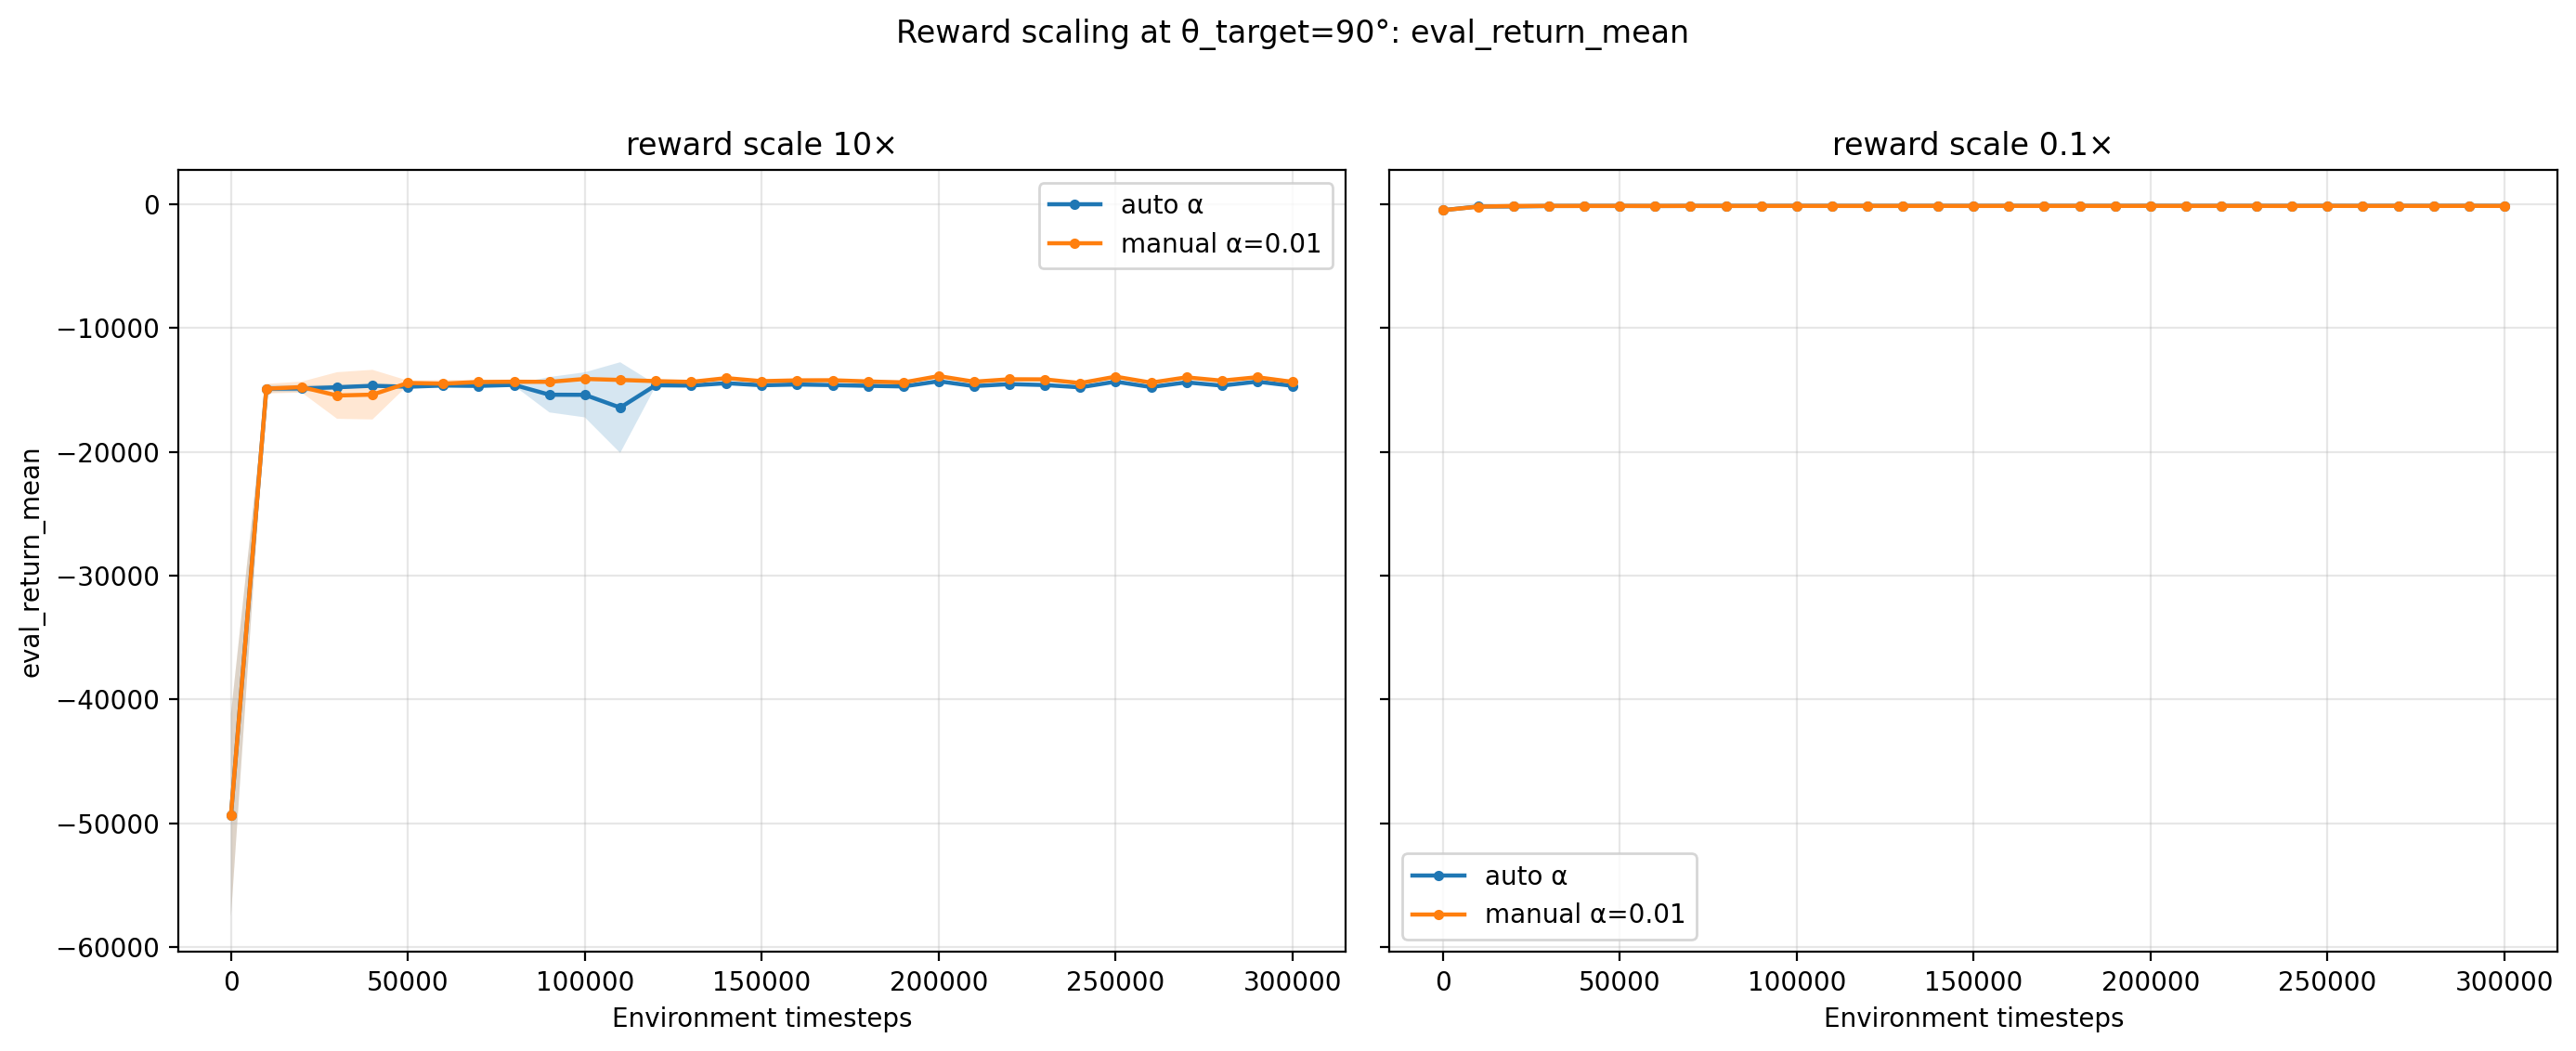

../outputs/pendulum_final_300k_clean/plots/auto_all_targets_mean_abs_angle_error_deg.png


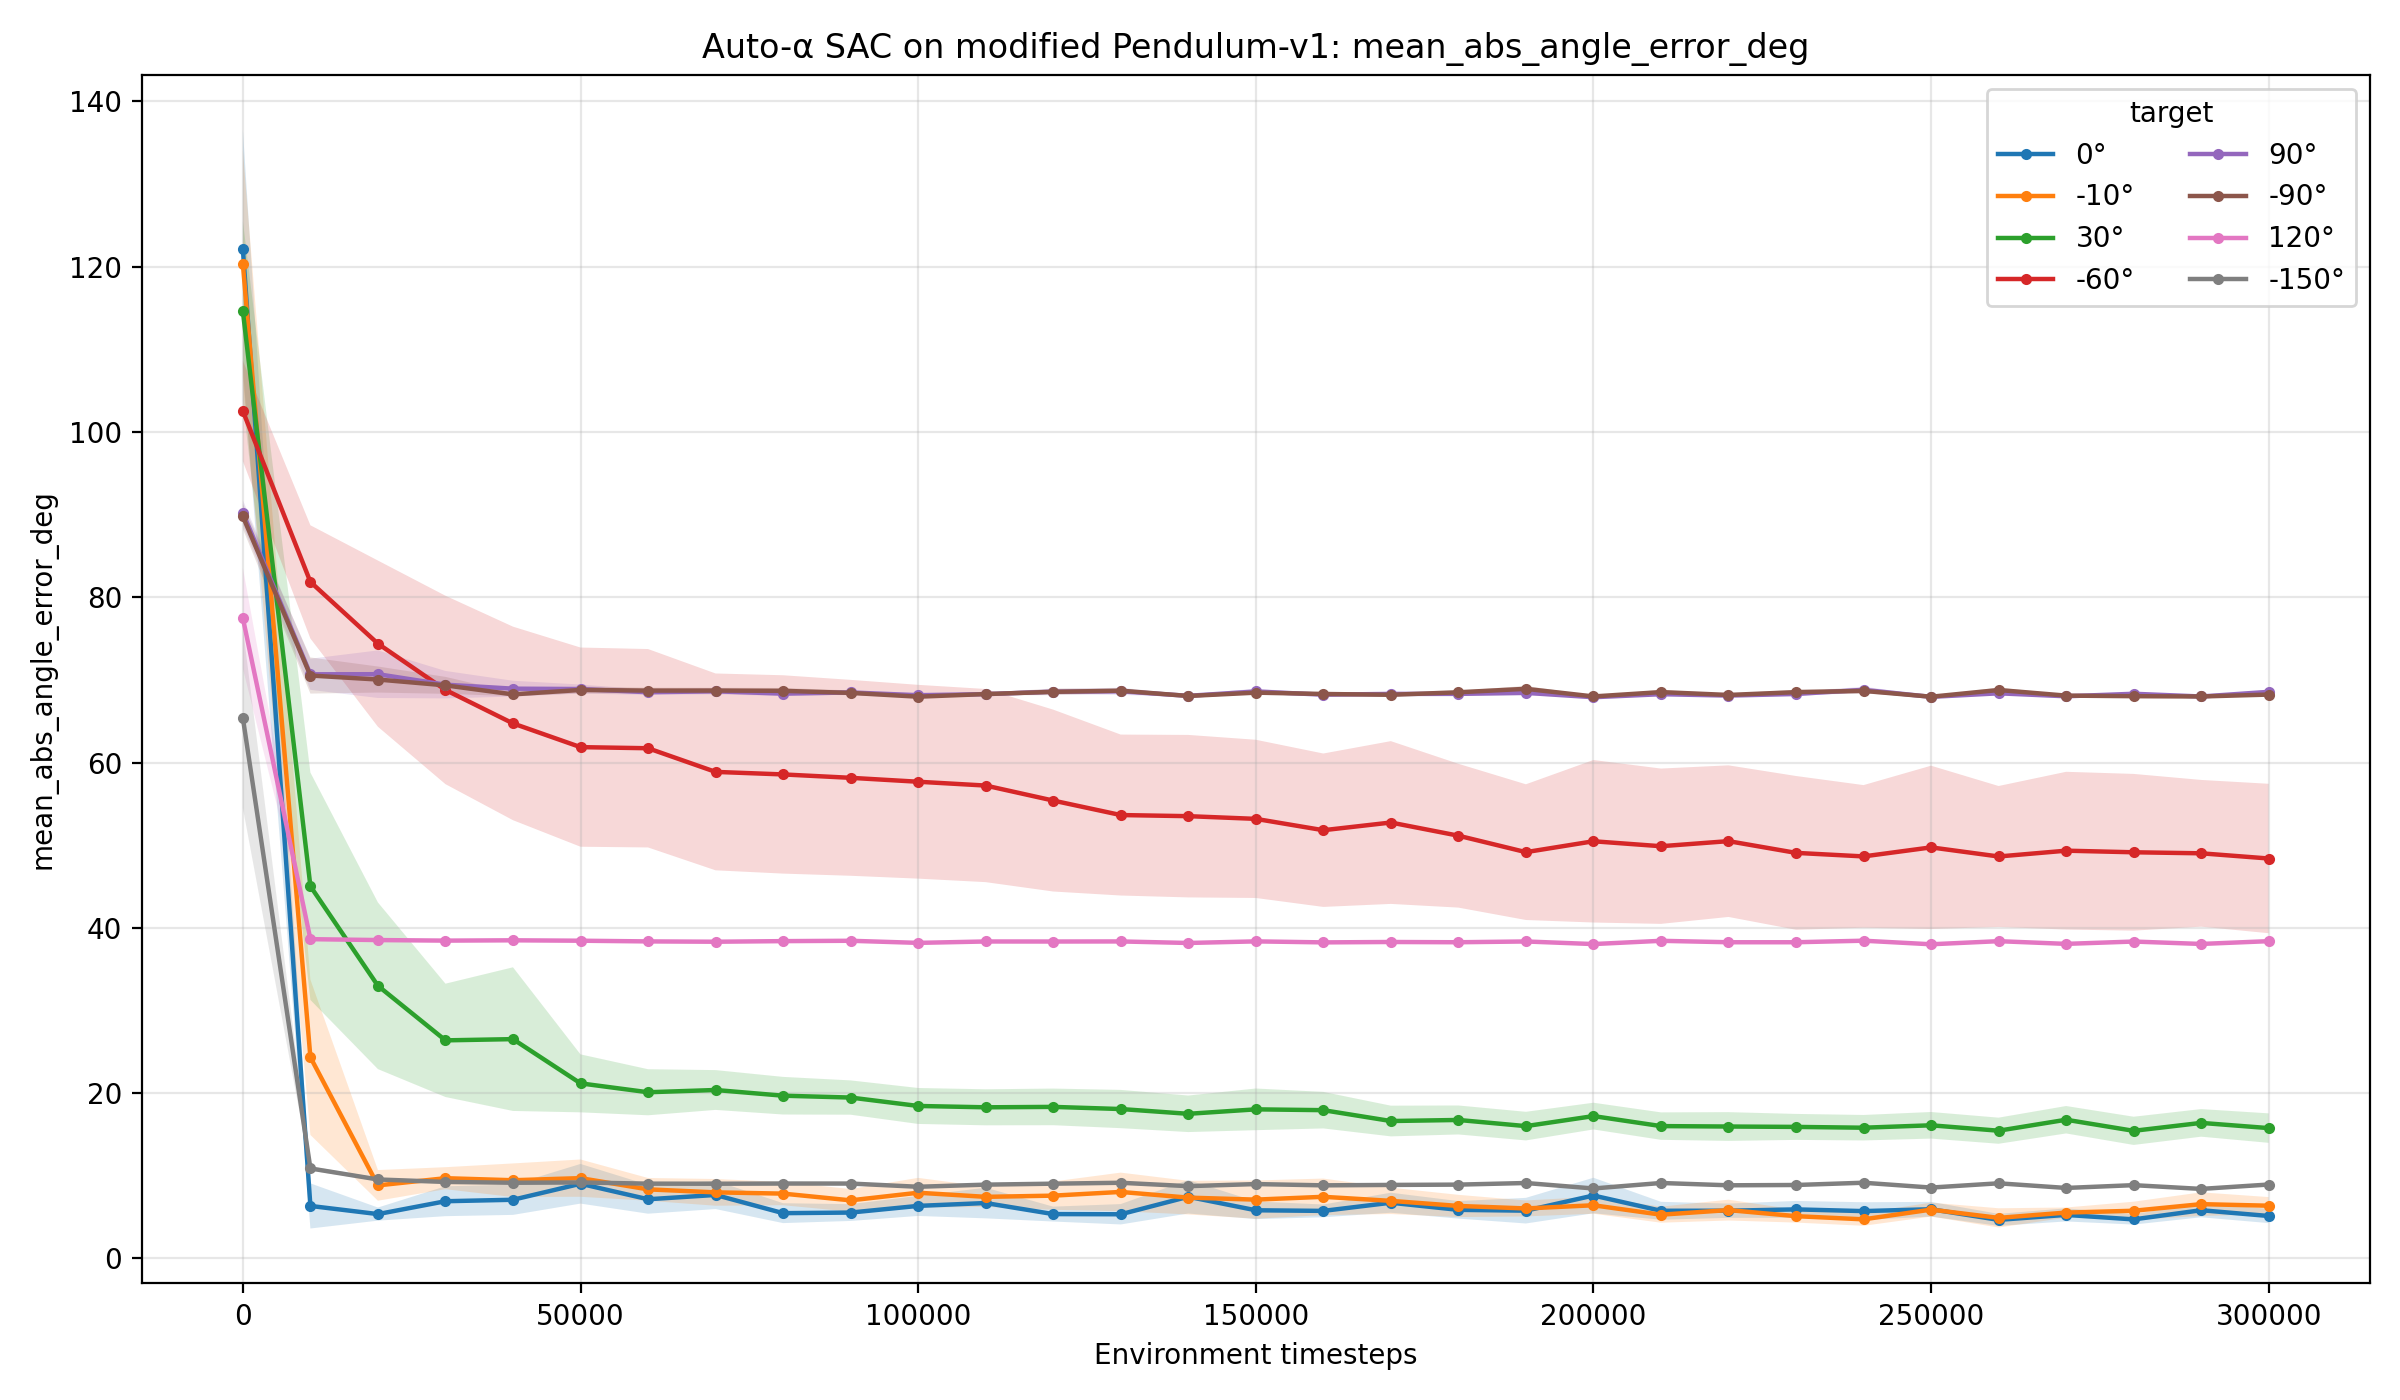

In [5]:
from IPython.display import Image, display
for name in [
    'auto_all_targets_eval_return_mean.png',
    'manual_vs_auto_panels_eval_return_mean.png',
    'reward_scaling_panels_eval_return_mean.png',
    'auto_all_targets_mean_abs_angle_error_deg.png',
]:
    p = PLOTS_DIR / name
    if p.exists():
        print(p)
        display(Image(filename=str(p)))

## Summary tables

In [6]:
for name in ['manual_alpha_selection_table.csv', 'summary_auto_final.csv', 'summary_manual_vs_auto_final.csv', 'summary_reward_scaling_final.csv']:
    p = OUTPUT_ROOT / name
    if p.exists():
        print('\n', name)
        display(pd.read_csv(p).head(20))


 manual_alpha_selection_table.csv


,target_angle_deg,manual_alpha,n_seeds,seeds_present,final_return,auc,final_return_norm,auc_norm,selection_score
0,-150.0,0.01,3,"0,1,2",-73.093501,-4.128188e+07,1.000000,0.997653,0.998827
1,-150.0,0.03,3,"0,1,2",-82.051004,-4.120000e+07,0.931906,1.000000,0.965953
2,-150.0,0.05,3,"0,1,2",-89.162163,-4.297532e+07,0.877847,0.949116,0.913481
3,-150.0,0.10,3,"0,1,2",-105.143347,-4.738416e+07,0.756359,0.822750,0.789554
4,-150.0,0.20,3,"0,1,2",-137.223450,-5.674693e+07,0.512487,0.554396,0.533441
5,-150.0,0.50,3,"0,1,2",-204.638702,-7.608954e+07,0.000000,0.000000,0.000000
6,-60.0,0.03,3,"0,1,2",-573.587165,-2.313252e+08,1.000000,1.000000,1.000000
7,-60.0,0.05,3,"0,1,2",-585.699390,-2.414154e+08,0.968328,0.887953,0.928140
8,-60.0,0.01,3,"0,1,2",-589.389933,-2.407752e+08,0.958678,0.895061,0.926870
9,-60.0,0.10,3,"0,1,2",-657.661715,-2.487400e+08,0.780156,0.806616,0.793386



 summary_auto_final.csv


,table,target_angle_deg,metric,mean,std,n_seeds,ci95
0,auto_final,0,eval_return_mean,-153.084336,13.834225,15,7.001084
1,auto_final,0,mean_abs_angle_error_deg,5.127903,1.695840,15,0.858213
2,auto_final,0,target_occupancy,0.965203,0.003239,15,0.001639
3,auto_final,0,mean_squared_torque,0.208618,0.145277,15,0.073520
4,auto_final,0,alpha,0.008022,0.003967,15,0.002008
5,auto_final,-10,eval_return_mean,-156.639481,14.439465,15,7.307378
6,auto_final,-10,mean_abs_angle_error_deg,6.372969,2.062477,15,1.043758
7,auto_final,-10,target_occupancy,0.957800,0.013353,15,0.006757
8,auto_final,-10,mean_squared_torque,0.918727,0.560546,15,0.283676
9,auto_final,-10,alpha,0.010602,0.006661,15,0.003371



 summary_manual_vs_auto_final.csv


,target_angle_deg,agent,manual_alpha,final_step,final_return_mean_over_seeds,final_return_std_over_seeds,n_seeds,ci95
0,-60,auto,NaN,300000,-903.542419,728.663485,15,368.754602
1,-60,manual,0.03,300000,-884.162320,644.391743,15,326.107216
2,90,auto,NaN,300000,-1468.745676,19.609723,15,9.923889
3,90,manual,0.01,300000,-1429.218348,20.054093,15,10.148771
4,120,auto,NaN,300000,-496.505949,3.954112,15,2.001057
5,120,manual,0.01,300000,-478.036908,4.346262,15,2.199512
6,-150,auto,NaN,300000,-72.793992,5.999528,15,3.036180
7,-150,manual,0.01,300000,-72.994370,5.780367,15,2.925269



 summary_reward_scaling_final.csv


,reward_scale,agent,final_step,final_return_mean_over_seeds,final_return_std_over_seeds,n_seeds,ci95
0,10.0,auto_scaled,300000,-14674.889861,118.675493,15,60.058086
1,10.0,manual_scaled,300000,-14359.797620,342.118908,15,173.136056
2,0.1,auto_scaled,300000,-145.299417,0.850904,15,0.430617
3,0.1,manual_scaled,300000,-147.694785,0.978713,15,0.495297


## Generate rollout videos/GIFs

In [7]:
!python ../make_pendulum_videos.py --output-root {OUTPUT_ROOT} --include-manual --include-scaling --ext gif --checkpoint best_model.pt

Wrote 16 videos to ../outputs/pendulum_final_300k_clean/videos
  ../outputs/pendulum_final_300k_clean/videos/auto_target_p000.gif
  ../outputs/pendulum_final_300k_clean/videos/auto_target_m010.gif
  ../outputs/pendulum_final_300k_clean/videos/auto_target_p030.gif
  ../outputs/pendulum_final_300k_clean/videos/auto_target_m060.gif
  ../outputs/pendulum_final_300k_clean/videos/auto_target_p090.gif
  ../outputs/pendulum_final_300k_clean/videos/auto_target_m090.gif
  ../outputs/pendulum_final_300k_clean/videos/auto_target_p120.gif
  ../outputs/pendulum_final_300k_clean/videos/auto_target_m150.gif
  ../outputs/pendulum_final_300k_clean/videos/manual_target_m060_alpha_0p03.gif
  ../outputs/pendulum_final_300k_clean/videos/manual_target_p090_alpha_0p01.gif
  ../outputs/pendulum_final_300k_clean/videos/manual_target_p120_alpha_0p01.gif
  ../outputs/pendulum_final_300k_clean/videos/manual_target_m150_alpha_0p01.gif
  ../outputs/pendulum_final_300k_clean/videos/auto_target_p090_scale_10.gif
  ../

## Display a sample GIF

num gifs: 16


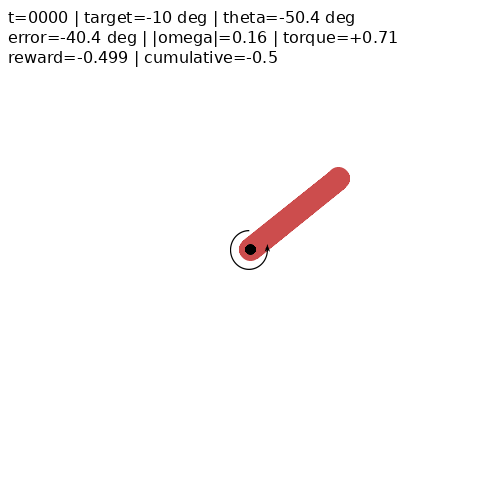

In [8]:
from IPython.display import Image, display
gifs = sorted(VIDEOS_DIR.glob('*.gif'))
print('num gifs:', len(gifs))
if gifs:
    display(Image(filename=str(gifs[0])))